# Austin FC Sales History — Full Data Audit

## Dataset

**Source table:** `austin_fc_sales_history_updated_2026_09_24`

This notebook performs a full-data audit of the updated Austin FC sales history dataset.

### Analysis approach

The dataset contains more than 5 million records, so the notebook does **not** load the complete raw table into pandas. Instead:

- PostgreSQL performs full-table calculations and aggregations.
- Python and pandas analyze the resulting summary datasets.
- Matplotlib creates the visualizations.
- A small raw-data sample is used only for inspection.

This approach allows the analysis to use the complete dataset while keeping memory usage reasonable on a local Ubuntu system.

**Important:** All revenue, transaction, missingness, payment, product, channel, and time-series statistics below are calculated from the complete PostgreSQL table unless explicitly identified as a sample.


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

# ------------------------------------------------------------
# Locate the project directory and load .env
# ------------------------------------------------------------

PROJECT_DIR = Path.home() / "data-analysis"
ENV_FILE = PROJECT_DIR / ".env"

if not ENV_FILE.exists():
    raise FileNotFoundError(
        f"Database configuration file was not found: {ENV_FILE}"
    )

load_dotenv(ENV_FILE, override=False)

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

required_variables = {
    "DB_USER": DB_USER,
    "DB_PASSWORD": DB_PASSWORD,
    "DB_HOST": DB_HOST,
    "DB_PORT": DB_PORT,
    "DB_NAME": DB_NAME,
}

missing_variables = [
    name for name, value in required_variables.items()
    if not value
]

if missing_variables:
    raise RuntimeError(
        "Missing database environment variables: "
        + ", ".join(missing_variables)
    )

TABLE_NAME = "austin_fc_sales_history_updated_2026_09_24"

db_url = URL.create(
    "postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=int(DB_PORT),
    database=DB_NAME,
)

engine = create_engine(db_url)

print("Project directory:", PROJECT_DIR)
print("Environment file:", ENV_FILE)
print("Database:", DB_NAME)
print("Host:", DB_HOST)
print("Port:", DB_PORT)
print("User:", DB_USER)
print("Table:", TABLE_NAME)
print("Database configuration loaded successfully.")


Python: 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]
pandas: 3.0.6
numpy: 2.5.3
Project directory: /home/jeremiah/data-analysis
Environment file: /home/jeremiah/data-analysis/.env
Database: data_analysis
Host: localhost
Port: 5432
User: dataanalyst
Table: austin_fc_sales_history_updated_2026_09_24
Database configuration loaded successfully.


In [2]:
with engine.connect() as connection:
    result = connection.execute(
        text("SELECT current_database(), current_user;")
    ).fetchone()

print("Connected successfully.")
print("Database:", result[0])
print("User:", result[1])


Connected successfully.
Database: data_analysis
User: dataanalyst


## 1. Dataset Structure

In [3]:
schema_query = f'''
SELECT
    column_name,
    data_type,
    is_nullable
FROM information_schema.columns
WHERE table_name = '{TABLE_NAME}'
ORDER BY ordinal_position;
'''

schema_df = pd.read_sql(schema_query, engine)
schema_df


,column_name,data_type,is_nullable
0,primary_ticket_id,text,YES
1,subscription_instance_id,text,YES
2,sales_item_id,text,YES
3,product_item_id,text,YES
4,transaction_id,text,YES
5,product_id,text,YES
6,internal_account_id,text,YES
7,sales_rep,text,YES
8,transaction_date,timestamp without time zone,YES
9,last_touched_at,timestamp with time zone,YES


## 2. Full Dataset Size and Coverage

In [4]:
dataset_overview_query = f'''
SELECT
    COUNT(*) AS total_rows,
    MIN(transaction_date) AS first_transaction,
    MAX(transaction_date) AS last_transaction,
    COUNT(DISTINCT transaction_id) AS distinct_transactions,
    COUNT(DISTINCT product_id) AS distinct_products
FROM {TABLE_NAME};
'''

dataset_overview = pd.read_sql(dataset_overview_query, engine)
dataset_overview


,total_rows,first_transaction,last_transaction,distinct_transactions,distinct_products
0,5335362,2019-08-15 18:42:04.997,2026-09-24 20:04:57.997,1533468,585


In [5]:
total_rows = int(dataset_overview.loc[0, "total_rows"])
distinct_transactions = int(dataset_overview.loc[0, "distinct_transactions"])

print(f"Total rows: {total_rows:,}")
print(f"Distinct transaction IDs: {distinct_transactions:,}")
print(f"Duplicate transaction-ID difference: {total_rows - distinct_transactions:,}")
print(f"First transaction: {dataset_overview.loc[0, 'first_transaction']}")
print(f"Last transaction: {dataset_overview.loc[0, 'last_transaction']}")


Total rows: 5,335,362
Distinct transaction IDs: 1,533,468
Duplicate transaction-ID difference: 3,801,894
First transaction: 2019-08-15 18:42:04.997000
Last transaction: 2026-09-24 20:04:57.997000


## 3. Full-Data Payment Analysis

In [6]:
payment_query = f'''
SELECT
    COUNT(*) AS transaction_count,
    SUM(total_payment) AS total_revenue,
    AVG(total_payment) AS average_payment,
    MIN(total_payment) AS minimum_payment,
    MAX(total_payment) AS maximum_payment,
    PERCENTILE_CONT(0.01) WITHIN GROUP (ORDER BY total_payment) AS p01,
    PERCENTILE_CONT(0.05) WITHIN GROUP (ORDER BY total_payment) AS p05,
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY total_payment) AS q1,
    PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY total_payment) AS median,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY total_payment) AS q3,
    PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY total_payment) AS p90,
    PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY total_payment) AS p95,
    PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY total_payment) AS p99
FROM {TABLE_NAME};
'''

payment_stats = pd.read_sql(payment_query, engine)
payment_stats.T


,0
transaction_count,5.335362e+06
total_revenue,4.829078e+08
average_payment,9.051079e+01
minimum_payment,0.000000e+00
maximum_payment,2.930252e+05
p01,0.000000e+00
p05,0.000000e+00
q1,0.000000e+00
median,3.562000e+01
q3,6.951000e+01


In [7]:
payment_special_query = f'''
SELECT
    COUNT(*) FILTER (WHERE total_payment = 0) AS zero_payment_rows,
    COUNT(*) FILTER (WHERE total_payment < 0) AS negative_payment_rows,
    COUNT(*) FILTER (WHERE total_payment > 0) AS positive_payment_rows,
    COUNT(*) FILTER (WHERE total_payment IS NULL) AS null_payment_rows
FROM {TABLE_NAME};
'''

payment_special = pd.read_sql(payment_special_query, engine)
payment_special


,zero_payment_rows,negative_payment_rows,positive_payment_rows,null_payment_rows
0,2069655,0,3265707,0


## 4. Full-Data Missingness Analysis

In [8]:
missingness_query = f'''
SELECT
    COUNT(*) AS total_rows,

    COUNT(*) FILTER (WHERE primary_ticket_id IS NULL) AS missing_primary_ticket_id,
    COUNT(*) FILTER (WHERE subscription_instance_id IS NULL) AS missing_subscription_instance_id,
    COUNT(*) FILTER (WHERE sales_item_id IS NULL) AS missing_sales_item_id,
    COUNT(*) FILTER (WHERE product_item_id IS NULL) AS missing_product_item_id,
    COUNT(*) FILTER (WHERE transaction_id IS NULL) AS missing_transaction_id,
    COUNT(*) FILTER (WHERE product_id IS NULL) AS missing_product_id,
    COUNT(*) FILTER (WHERE transaction_date IS NULL) AS missing_transaction_date,
    COUNT(*) FILTER (WHERE total_payment IS NULL) AS missing_total_payment,
    COUNT(*) FILTER (WHERE product_type IS NULL) AS missing_product_type,
    COUNT(*) FILTER (WHERE application_channel IS NULL) AS missing_application_channel,
    COUNT(*) FILTER (WHERE section IS NULL) AS missing_section,
    COUNT(*) FILTER (WHERE row IS NULL) AS missing_row,
    COUNT(*) FILTER (WHERE seat IS NULL) AS missing_seat,
    COUNT(*) FILTER (WHERE product_description IS NULL) AS missing_product_description,
    COUNT(*) FILTER (WHERE sales_rep IS NULL) AS missing_sales_rep,
    COUNT(*) FILTER (WHERE sale_type IS NULL) AS missing_sale_type,
    COUNT(*) FILTER (WHERE price_level IS NULL) AS missing_price_level,
    COUNT(*) FILTER (WHERE price_type IS NULL) AS missing_price_type,
    COUNT(*) FILTER (WHERE price_type_group IS NULL) AS missing_price_type_group,
    COUNT(*) FILTER (WHERE is_hospitality IS NULL) AS missing_is_hospitality

FROM {TABLE_NAME};
'''

missingness = pd.read_sql(missingness_query, engine)

missingness_long = (
    missingness.T
    .reset_index()
    .rename(columns={"index": "field", 0: "missing_count"})
)

missingness_long = missingness_long[missingness_long["field"] != "total_rows"].copy()
missingness_long["missing_percent"] = (
    missingness_long["missing_count"] / total_rows * 100
)

missingness_long.sort_values("missing_count", ascending=False)


,field,missing_count,missing_percent
15,missing_sales_rep,4882707,91.515946
20,missing_is_hospitality,2054507,38.507359
2,missing_subscription_instance_id,1937352,36.311538
19,missing_price_type_group,506115,9.486048
1,missing_primary_ticket_id,162859,3.052445
12,missing_row,156695,2.936914
13,missing_seat,156695,2.936914
11,missing_section,156695,2.936914
17,missing_price_level,3,0.000056
3,missing_sales_item_id,0,0.000000


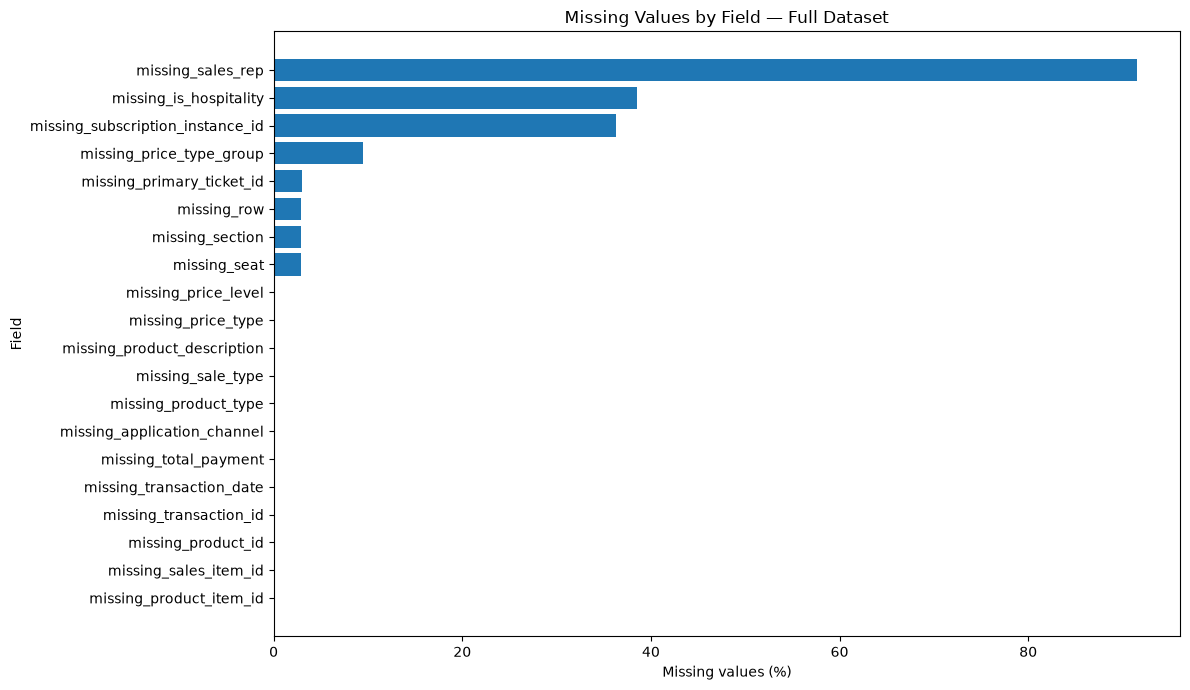

In [9]:
plt.figure(figsize=(12, 7))

plot_df = missingness_long.sort_values("missing_percent", ascending=True)

plt.barh(
    plot_df["field"],
    plot_df["missing_percent"]
)

plt.xlabel("Missing values (%)")
plt.ylabel("Field")
plt.title("Missing Values by Field — Full Dataset")
plt.tight_layout()
plt.show()


## 5. Missingness by Product Type

In [10]:
missing_by_product_query = f'''
SELECT
    product_type,
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (WHERE primary_ticket_id IS NULL) AS missing_primary_ticket_id,
    COUNT(*) FILTER (WHERE subscription_instance_id IS NULL) AS missing_subscription_instance_id,
    COUNT(*) FILTER (WHERE section IS NULL) AS missing_section,
    COUNT(*) FILTER (WHERE row IS NULL) AS missing_row,
    COUNT(*) FILTER (WHERE seat IS NULL) AS missing_seat
FROM {TABLE_NAME}
GROUP BY product_type
ORDER BY total_rows DESC;
'''

missing_by_product = pd.read_sql(missing_by_product_query, engine)
missing_by_product


,product_type,total_rows,missing_primary_ticket_id,missing_subscription_instance_id,missing_section,missing_row,missing_seat
0,Ticket,3117996,0,1212330,123834,123834,123834
1,Resale,2054507,0,725022,7540,7540,7540
2,Subscription,162859,162859,0,25321,25321,25321


## 6. Product-Type Analysis

In [11]:
product_query = f'''
SELECT
    product_type,
    COUNT(*) AS transactions,
    SUM(total_payment) AS revenue,
    AVG(total_payment) AS average_payment,
    MIN(total_payment) AS minimum_payment,
    MAX(total_payment) AS maximum_payment
FROM {TABLE_NAME}
GROUP BY product_type
ORDER BY revenue DESC;
'''

product_summary = pd.read_sql(product_query, engine)
product_summary


,product_type,transactions,revenue,average_payment,minimum_payment,maximum_payment
0,Ticket,3117996,2.508378e+08,80.448398,0.0,293025.20
1,Subscription,162859,1.864373e+08,1144.777097,0.0,17652.47
2,Resale,2054507,4.563277e+07,22.211055,0.0,3176.55


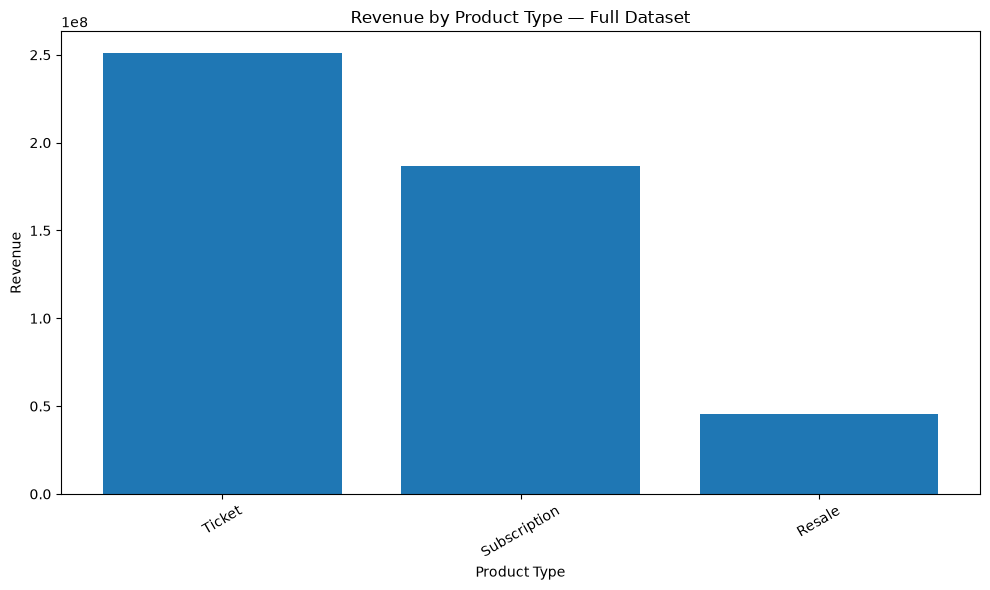

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(
    product_summary["product_type"].astype(str),
    product_summary["revenue"]
)

plt.xlabel("Product Type")
plt.ylabel("Revenue")
plt.title("Revenue by Product Type — Full Dataset")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 7. Application Channel Analysis

In [13]:
channel_query = f'''
SELECT
    application_channel,
    COUNT(*) AS transactions,
    SUM(total_payment) AS revenue,
    AVG(total_payment) AS average_payment
FROM {TABLE_NAME}
GROUP BY application_channel
ORDER BY revenue DESC;
'''

channel_summary = pd.read_sql(channel_query, engine)
channel_summary


,application_channel,transactions,revenue,average_payment
0,Internal,1882587,2.591929e+08,137.679100
1,bSRO,639498,1.140837e+08,178.395695
2,eSRO,2813277,1.096312e+08,38.969227


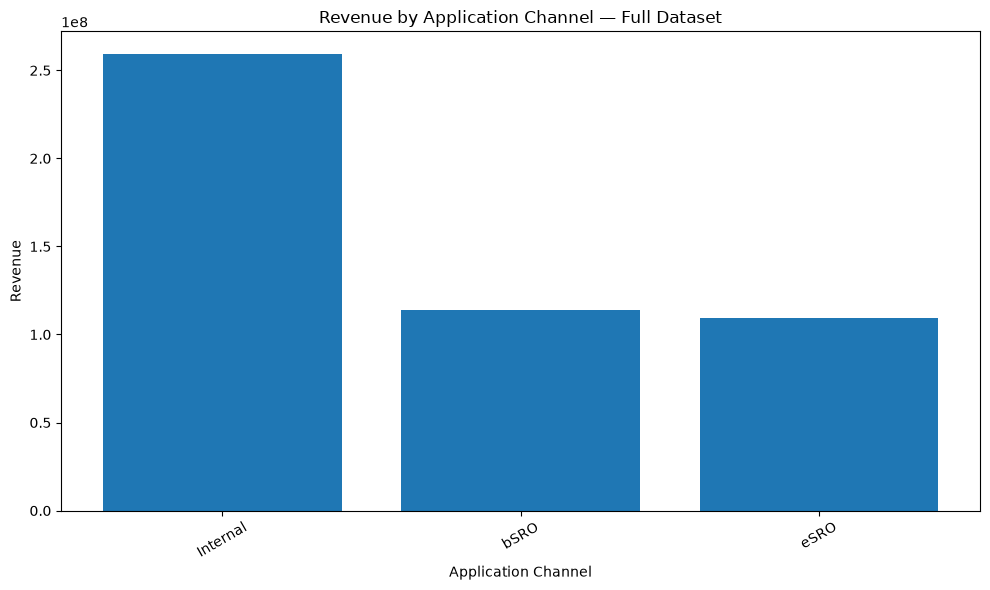

In [14]:
plt.figure(figsize=(10, 6))

plt.bar(
    channel_summary["application_channel"].astype(str),
    channel_summary["revenue"]
)

plt.xlabel("Application Channel")
plt.ylabel("Revenue")
plt.title("Revenue by Application Channel — Full Dataset")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 8. Sale-Type Analysis

In [15]:
sale_type_query = f'''
SELECT
    sale_type,
    COUNT(*) AS transactions,
    SUM(total_payment) AS revenue,
    AVG(total_payment) AS average_payment
FROM {TABLE_NAME}
GROUP BY sale_type
ORDER BY revenue DESC;
'''

sale_type_summary = pd.read_sql(sale_type_query, engine)
sale_type_summary


,sale_type,transactions,revenue,average_payment
0,Sale,5103872,3.729374e+08,73.069511
1,Reservation Confirmation,231490,1.099704e+08,475.054530


## 9. Hospitality Analysis

In [16]:
hospitality_query = f'''
SELECT
    is_hospitality,
    COUNT(*) AS transactions,
    SUM(total_payment) AS revenue,
    AVG(total_payment) AS average_payment
FROM {TABLE_NAME}
GROUP BY is_hospitality
ORDER BY is_hospitality;
'''

hospitality_summary = pd.read_sql(hospitality_query, engine)
hospitality_summary


,is_hospitality,transactions,revenue,average_payment
0,False,3280855,437275035.9,133.280817
1,None,2054507,45632769.0,22.211055


## 10. Price-Level Analysis

In [17]:
price_level_query = f'''
SELECT
    price_level,
    COUNT(*) AS transactions,
    SUM(total_payment) AS revenue,
    AVG(total_payment) AS average_payment
FROM {TABLE_NAME}
GROUP BY price_level
ORDER BY revenue DESC
LIMIT 25;
'''

price_level_summary = pd.read_sql(price_level_query, engine)
price_level_summary


,price_level,transactions,revenue,average_payment
0,Supporters A,830879,31797491.55,38.269702
1,West Club C,88186,25838553.08,293.000625
2,West Club D,87172,22579789.30,259.025711
3,West Club B,76503,19730252.90,257.901689
4,Lower North B,366080,19409852.25,53.020794
5,Upper West B,166004,19336444.98,116.481802
6,East Club B,90212,18974743.27,210.335025
7,Lower East B,267966,17595401.00,65.662812
8,West Club A,53493,15562594.68,290.927685
9,Lower East A,198941,14986574.88,75.331756


## 11. Price-Type Analysis

In [18]:
price_type_query = f'''
SELECT
    price_type,
    COUNT(*) AS transactions,
    SUM(total_payment) AS revenue,
    AVG(total_payment) AS average_payment
FROM {TABLE_NAME}
GROUP BY price_type
ORDER BY revenue DESC
LIMIT 25;
'''

price_type_summary = pd.read_sql(price_type_query, engine)
price_type_summary


,price_type,transactions,revenue,average_payment
0,Full Season Regular Renewal,1829523,1.129800e+08,61.753792
1,Full Season Premium Renewal,392174,8.648856e+07,220.536190
2,Full Season Premium,142351,3.925631e+07,275.771259
3,Single Regular,338427,2.179866e+07,64.411694
4,Full Season Regular,362591,1.824220e+07,50.310680
5,Full Season Premium New,65095,1.465764e+07,225.172980
6,Full Season Premium 2% Renewal,28803,1.112105e+07,386.107408
7,Full Season Premium 2% '24EXP Renewal,22225,8.369695e+06,376.589222
8,Full Season Premium 2% LC Renewal,21568,7.841775e+06,363.583773
9,Single Premium Hospitality,44204,7.786780e+06,176.155560


## 12. Monthly Sales Analysis

In [19]:
monthly_query = f'''
SELECT
    DATE_TRUNC('month', transaction_date) AS transaction_month,
    COUNT(*) AS transactions,
    SUM(total_payment) AS revenue,
    AVG(total_payment) AS average_payment
FROM {TABLE_NAME}
GROUP BY DATE_TRUNC('month', transaction_date)
ORDER BY transaction_month;
'''

monthly_sales = pd.read_sql(monthly_query, engine)
monthly_sales["transaction_month"] = pd.to_datetime(
    monthly_sales["transaction_month"]
)

monthly_sales


,transaction_month,transactions,revenue,average_payment
0,2019-08-01,18,900.00,50.000000
1,2019-10-01,26,1850.00,71.153846
2,2019-11-01,10943,8934594.88,816.466680
3,2019-12-01,7327,4544212.00,620.200901
4,2020-01-01,8867,3442968.13,388.290079
...,...,...,...,...
80,2026-05-01,37590,1032122.03,27.457356
81,2026-06-01,16877,1147306.31,67.980465
82,2026-07-01,65262,12162995.18,186.371781
83,2026-08-01,90103,3503522.13,38.883524


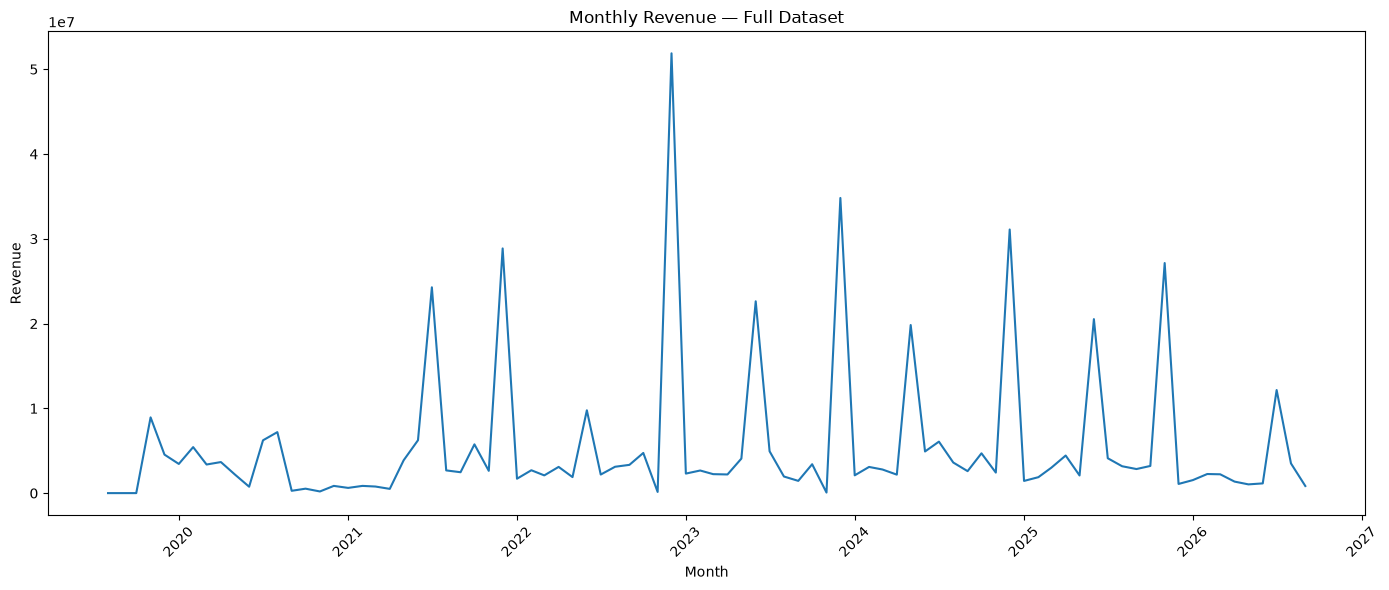

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["transaction_month"],
    monthly_sales["revenue"]
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue — Full Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


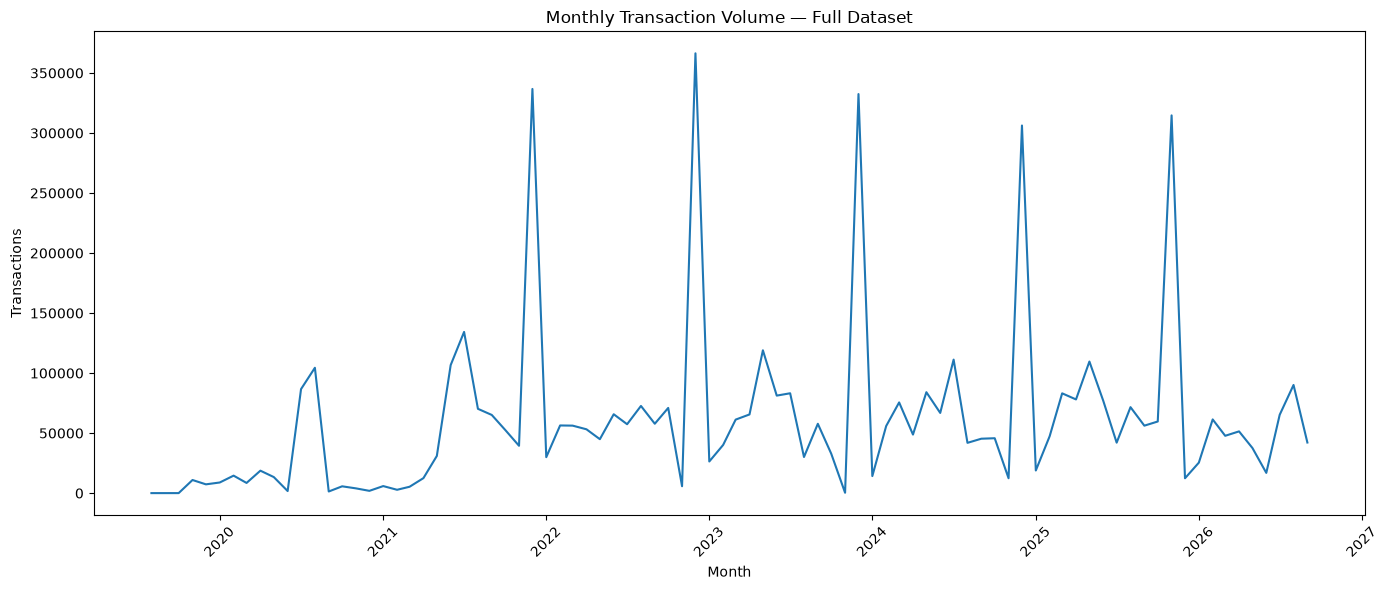

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["transaction_month"],
    monthly_sales["transactions"]
)

plt.xlabel("Month")
plt.ylabel("Transactions")
plt.title("Monthly Transaction Volume — Full Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


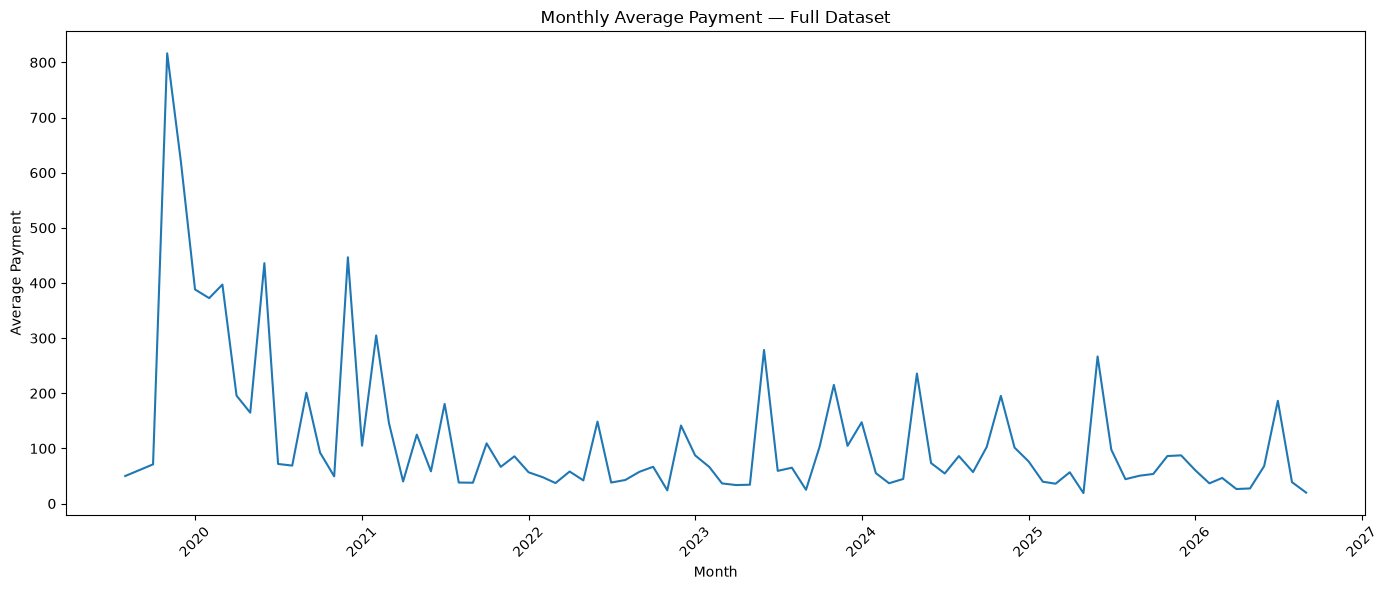

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["transaction_month"],
    monthly_sales["average_payment"]
)

plt.xlabel("Month")
plt.ylabel("Average Payment")
plt.title("Monthly Average Payment — Full Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 13. Yearly Sales Analysis

In [23]:
yearly_query = f'''
SELECT
    EXTRACT(YEAR FROM transaction_date)::int AS year,
    COUNT(*) AS transactions,
    SUM(total_payment) AS revenue,
    AVG(total_payment) AS average_payment
FROM {TABLE_NAME}
GROUP BY EXTRACT(YEAR FROM transaction_date)
ORDER BY year;
'''

yearly_sales = pd.read_sql(yearly_query, engine)
yearly_sales


,year,transactions,revenue,average_payment
0,2019,18314,13481556.88,736.133935
1,2020,269824,34151872.11,126.570921
2,2021,862688,79534221.38,92.193494
3,2022,937391,86635986.18,92.422464
4,2023,930201,82746953.57,88.955993
5,2024,908260,85386498.29,94.011074
6,2025,970663,74912388.20,77.176516
7,2026,438021,26058328.29,59.491048


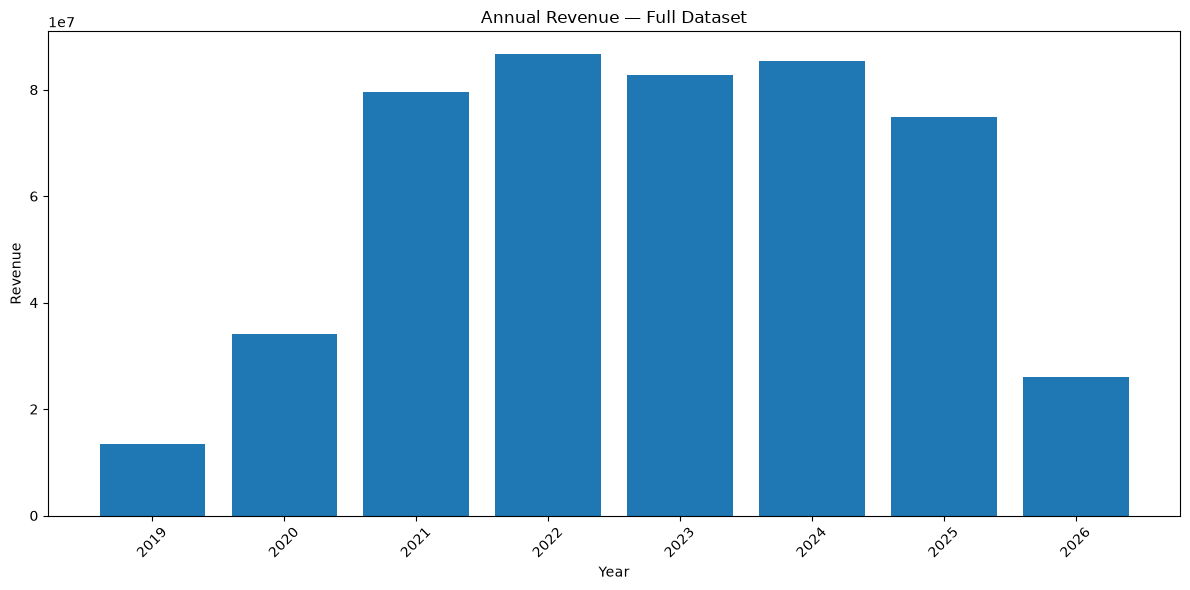

In [24]:
plt.figure(figsize=(12, 6))

plt.bar(
    yearly_sales["year"].astype(str),
    yearly_sales["revenue"]
)

plt.xlabel("Year")
plt.ylabel("Revenue")
plt.title("Annual Revenue — Full Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 14. Sales Representative Analysis

In [25]:
sales_rep_query = f'''
SELECT
    sales_rep,
    COUNT(*) AS transactions,
    SUM(total_payment) AS revenue,
    AVG(total_payment) AS average_payment
FROM {TABLE_NAME}
GROUP BY sales_rep
ORDER BY revenue DESC
LIMIT 20;
'''

sales_rep_summary = pd.read_sql(sales_rep_query, engine)
sales_rep_summary


,sales_rep,transactions,revenue,average_payment
0,NaN,4882707,3.773918e+08,77.291510
1,e13f0aed-8dc3-e911-a9ce-b4d295c803b4,26425,9.208490e+06,348.476442
2,cf3d0764-eeb6-ea11-a9ce-0a593f791696,17072,8.343443e+06,488.720913
3,32452853-d1ee-e911-a9ce-0a593f791696,20468,6.557978e+06,320.401505
4,64abfe91-edd5-ec11-8398-afdcd3d9b1c9,33777,5.782455e+06,171.195034
5,332a23ce-cdba-ee11-8444-f25803cab98d,11930,5.559434e+06,466.004567
6,f8cd53e7-a232-ed11-83d0-c079aa792785,17553,5.509189e+06,313.860272
7,aaa43811-d1ee-e911-a9ce-0a593f791696,19880,5.353364e+06,269.283903
8,68b2173b-d1ee-e911-a9ce-0a593f791696,15640,4.962572e+06,317.300000
9,c39bb46d-2525-eb11-828e-85d3c8e3831d,28312,4.961201e+06,175.233141


## 15. Duplicate Transaction Analysis

In [26]:
duplicate_query = f'''
SELECT
    COUNT(*) AS duplicate_transaction_groups,
    COALESCE(SUM(group_count), 0) AS rows_in_duplicate_groups
FROM (
    SELECT
        transaction_id,
        COUNT(*) AS group_count
    FROM {TABLE_NAME}
    WHERE transaction_id IS NOT NULL
    GROUP BY transaction_id
    HAVING COUNT(*) > 1
) d;
'''

duplicate_summary = pd.read_sql(duplicate_query, engine)
duplicate_summary


,duplicate_transaction_groups,rows_in_duplicate_groups
0,890471,4692365.0


## 16. Raw Data Inspection Sample

The following query retrieves only 1,000 rows for visual inspection. It is **not** used for the full-data statistics above.


In [27]:
sample_query = f'''
SELECT *
FROM {TABLE_NAME}
LIMIT 1000;
'''

sample_df = pd.read_sql(sample_query, engine)

print("Sample rows:", len(sample_df))
print("Sample columns:", len(sample_df.columns))

sample_df.head()


Sample rows: 1000
Sample columns: 27


,primary_ticket_id,subscription_instance_id,sales_item_id,product_item_id,transaction_id,product_id,internal_account_id,sales_rep,transaction_date,last_touched_at,...,price_type,price_type_group,total_payment,total_plan_amount,section,row,seat,product_description,application_channel,is_hospitality
0,25ee3fa2-3dbe-eb11-830a-d742523585ac,NaN,7fd037a8-3dbe-eb11-830a-d742523585ac,25ee3fa2-3dbe-eb11-830a-d742523585ac,1ee04c90-3dbe-eb11-830a-d742523585ac,88404095-5952-4ef1-804d-5bf864f028b3,fe7a63ec31d2177f025cedd0b124695582cf5705208b51...,None,2021-05-26 16:16:04.980,2026-04-13 08:43:33.184542+00:00,...,Presale Regular,Presale Single Match,69.6,0.0,229,7,10,Portland Timbers at Austin FC 7/1,eSRO,False
1,26ee3fa2-3dbe-eb11-830a-d742523585ac,NaN,80d037a8-3dbe-eb11-830a-d742523585ac,26ee3fa2-3dbe-eb11-830a-d742523585ac,1ee04c90-3dbe-eb11-830a-d742523585ac,88404095-5952-4ef1-804d-5bf864f028b3,fe7a63ec31d2177f025cedd0b124695582cf5705208b51...,None,2021-05-26 16:16:04.980,2026-04-13 08:43:33.184542+00:00,...,Presale Regular,Presale Single Match,69.6,0.0,229,7,11,Portland Timbers at Austin FC 7/1,eSRO,False
2,27ee3fa2-3dbe-eb11-830a-d742523585ac,NaN,81d037a8-3dbe-eb11-830a-d742523585ac,27ee3fa2-3dbe-eb11-830a-d742523585ac,1ee04c90-3dbe-eb11-830a-d742523585ac,88404095-5952-4ef1-804d-5bf864f028b3,fe7a63ec31d2177f025cedd0b124695582cf5705208b51...,None,2021-05-26 16:16:04.980,2026-04-13 08:43:33.184542+00:00,...,Presale Regular,Presale Single Match,69.6,0.0,229,7,12,Portland Timbers at Austin FC 7/1,eSRO,False
3,45eb3fa2-3dbe-eb11-830a-d742523585ac,NaN,9bd037a8-3dbe-eb11-830a-d742523585ac,45eb3fa2-3dbe-eb11-830a-d742523585ac,c0cd469c-3dbe-eb11-830a-d742523585ac,c9278231-37e1-48c1-a9f0-f48bf3e52c4e,96a1f18812e895598e42b3289c48f654f14312a466274f...,None,2021-05-26 16:16:05.220,2026-04-13 08:43:33.184542+00:00,...,Presale Regular,Presale Single Match,78.8,0.0,125,1,9,Columbus Crew at Austin FC 6/27,eSRO,False
4,46eb3fa2-3dbe-eb11-830a-d742523585ac,NaN,9cd037a8-3dbe-eb11-830a-d742523585ac,46eb3fa2-3dbe-eb11-830a-d742523585ac,c0cd469c-3dbe-eb11-830a-d742523585ac,c9278231-37e1-48c1-a9f0-f48bf3e52c4e,96a1f18812e895598e42b3289c48f654f14312a466274f...,None,2021-05-26 16:16:05.220,2026-04-13 08:43:33.184542+00:00,...,Presale Regular,Presale Single Match,78.8,0.0,125,1,10,Columbus Crew at Austin FC 6/27,eSRO,False


In [28]:
sample_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   primary_ticket_id         998 non-null    str                
 1   subscription_instance_id  10 non-null     str                
 2   sales_item_id             1000 non-null   str                
 3   product_item_id           1000 non-null   str                
 4   transaction_id            1000 non-null   str                
 5   product_id                1000 non-null   str                
 6   internal_account_id       1000 non-null   str                
 7   sales_rep                 0 non-null      object             
 8   transaction_date          1000 non-null   datetime64[us]     
 9   last_touched_at           1000 non-null   datetime64[us, UTC]
 10  item_type                 1000 non-null   str                
 11  product_type              100

## 17. Final Full-Data Audit Summary

In [29]:
print("=" * 70)
print("AUSTIN FC SALES HISTORY — FULL DATA AUDIT")
print("=" * 70)

print(f"Table: {TABLE_NAME}")
print(f"Rows: {total_rows:,}")
print(f"Distinct transaction IDs: {distinct_transactions:,}")
print(f"First transaction: {dataset_overview.loc[0, 'first_transaction']}")
print(f"Last transaction: {dataset_overview.loc[0, 'last_transaction']}")

print()
print(f"Total revenue: ${float(payment_stats.loc[0, 'total_revenue']):,.2f}")
print(f"Average payment: ${float(payment_stats.loc[0, 'average_payment']):,.2f}")
print(f"Median payment: ${float(payment_stats.loc[0, 'median']):,.2f}")
print(f"Minimum payment: ${float(payment_stats.loc[0, 'minimum_payment']):,.2f}")
print(f"Maximum payment: ${float(payment_stats.loc[0, 'maximum_payment']):,.2f}")

print()
print(f"Zero-payment rows: {int(payment_special.loc[0, 'zero_payment_rows']):,}")
print(f"Negative-payment rows: {int(payment_special.loc[0, 'negative_payment_rows']):,}")
print(f"Missing payment rows: {int(payment_special.loc[0, 'null_payment_rows']):,}")

print()
print("Top product type by revenue:")
print(product_summary.iloc[0]["product_type"])

print()
print("Top application channel by revenue:")
print(channel_summary.iloc[0]["application_channel"])

print()
print("Audit complete. Full-data calculations were performed in PostgreSQL.")
print("Python/pandas was used for summary analysis and visualization.")


AUSTIN FC SALES HISTORY — FULL DATA AUDIT
Table: austin_fc_sales_history_updated_2026_09_24
Rows: 5,335,362
Distinct transaction IDs: 1,533,468
First transaction: 2019-08-15 18:42:04.997000
Last transaction: 2026-09-24 20:04:57.997000

Total revenue: $482,907,804.90
Average payment: $90.51
Median payment: $35.62
Minimum payment: $0.00
Maximum payment: $293,025.20

Zero-payment rows: 2,069,655
Negative-payment rows: 0
Missing payment rows: 0

Top product type by revenue:
Ticket

Top application channel by revenue:
Internal

Audit complete. Full-data calculations were performed in PostgreSQL.
Python/pandas was used for summary analysis and visualization.


In [30]:
engine.dispose()
print("Database connection disposed.")


Database connection disposed.
